**Tujuan:** Menyelesaikan XOR classification problem menggunakan Multi-Layer Perceptron Neural Networks dengan struktur:
- 2 hidden units
- Sigmoid activation function


## **1. Import Library**

In [37]:
import numpy as np
import matplotlib.pyplot as plt

Library yang digunakan:
- NumPy: Untuk perhitungan
- Matplotlib: Untuk plot grafik

## **2. Dataset XOR**
| I1 | I2 | Target |
|----|----|---------|
| 0  | 0  | 0       |
| 0  | 1  | 1       |
| 1  | 0  | 1       |
| 1  | 1  | 0       |

XOR menghasilkan output **1** hanya jika **salah satu** input bernilai 1 (bukan keduanya).

In [38]:
# Input: 4 data points
X = np.array([[0, 0],[0, 1],[1, 0],[1, 1]])

# Target output XOR
T = np.array([[0],[1],[1],[0]])

print(f"{'I1':>4} {'I2':>4} {'Target':>8}")
for i in range(len(X)):
    print(f"{X[i,0]:>4} {X[i,1]:>4} {T[i,0]:>8}")

print(f"\nTotal data: {len(X)} input sequences")

  I1   I2   Target
   0    0        0
   0    1        1
   1    0        1
   1    1        0

Total data: 4 input sequences


Dataset XOR terdiri dari 4 input sequence dengan 2 input (I1, I2) dan 1 target output dimana XOR menghasilkan output **1** hanya jika **salah satu** input bernilai 1 (bukan keduanya).

## **3. Perhitungan XOR pada Single Perceptron**

Single Perceptron hanya mampu menyelesaikan masalah yang bersifat linearly separable (dapat dipisahkan dengan satu garis lurus), seperti AND, OR, dan AND-NOT. XOR bukan linearly separable, sehingga Single Perceptron akan gagal

Rumus learning Single Perceptron:
```
Err = Target - Output
Wj = Wj + μ * Ij * Err
```

In [39]:
np.random.seed(42)
w = np.random.uniform(-0.5, 0.5, size=3)  # w0 (bias), w1, w2
mu = 0.5   # learning rate
max_epochs = 100

print(f"\nInitial weights: w0={w[0]:.4f}, w1={w[1]:.4f}, w2={w[2]:.4f}")
print(f"Learning rate: {mu}")
print(f"Max epochs: {max_epochs}\n")

converged = False
for epoch in range(max_epochs):
    errors = 0
    for i in range(len(X)):
        # Input with bias
        inp = np.array([1, X[i, 0], X[i, 1]])
        # Summation
        summation = np.dot(w, inp)
        # Step activation (threshold = 0)
        output = 1 if summation >= 0 else 0
        # Error
        err = T[i, 0] - output
        if err != 0:
            errors += 1
            # Update weight
            w = w + mu * inp * err

# Test setelah training
print(f"{'I1':>4} {'I2':>4} {'Target':>8} {'Output':>8} {'Status':>8}")
print("-" * 40)
total_errors = 0
for i in range(len(X)):
    inp = np.array([1, X[i, 0], X[i, 1]])
    summation = np.dot(w, inp)
    output = 1 if summation >= 0 else 0
    status = "JOS" if output == T[i, 0] else "NOT"
    if output != T[i, 0]:
        total_errors += 1
    print(f"{X[i,0]:>4} {X[i,1]:>4} {T[i,0]:>8} {output:>8} {status:>8}")

print(f"\nTotal errors: {total_errors}/{len(X)}")
print(f"Error ratio: {total_errors/len(X)*100:.1f}%")


Initial weights: w0=-0.1255, w1=0.4507, w2=0.2320
Learning rate: 0.5
Max epochs: 100

  I1   I2   Target   Output   Status
----------------------------------------
   0    0        0        1      NOT
   0    1        1        1      JOS
   1    0        1        0      NOT
   1    1        0        0      JOS

Total errors: 2/4
Error ratio: 50.0%


Seperti yang diprediksi, Single Perceptron tidak mampu menyelesaikan XOR karena XOR bukan masalah yang linearly separable. Untuk menyelesaikan masalah ini, dibutuhkan **Multi-Layer Perceptron (MLP)** yang memiliki hidden layer

## **4. Definisi Fungsi Multi-Layer Perceptron (MLP)**
**Arsitektur MLP untuk XOR:**
![image.png](image.png)
- **Input layer:** 2 neuron (I1, I2) + 1 bias
- **Hidden layer:** 2 neuron (H1, H2) + 1 bias
- **Output layer:** 1 neuron (C)
- **Activation:** Sigmoid → `y = 1/(1+e^(-x))`, turunan: `y' = y*(1-y)`

**Rumus Backpropagation:**
```
dC  = C*(1-C)*(Target-C)
dH1 = H1*(1-H1)*wh1*dC
dH2 = H2*(1-H2)*wh2*dC

dwh(i) = μ * Hi * dC
wh(i)  = wh(i) + dwh(i)

dwi(r,i) = μ * Ir * dHi
wi(r,i)  = wi(r,i) + dwi(r,i)
```

In [40]:
def sigmoid(x):
    # Activation function: y = 1 / (1 + e^(-x))
    return 1.0 / (1.0 + np.exp(-x))

def sigmoid_derivative(y):
    # Turunan sigmoid: y' = y * (1 - y)
    return y * (1.0 - y)

def forward_pass(X_input, wi, wh):
    '''
    Feed Forward pass
    X_input : single input [I1, I2]
    wi      : weight input-to-hidden (3x2) - termasuk bias row
    wh      : weight hidden-to-output (3,)  - termasuk bias
    Returns: I, H1, H2, H, C
    '''
    # Input layer (tambah bias = 1)
    I = np.array([1.0, X_input[0], X_input[1]])  # [bias, I1, I2]
    
    # Hidden layer - Summation (SI)
    SI1 = np.dot(I, wi[:, 0])  # SI1 = wi(0,1)*1 + wi(1,1)*I1 + wi(2,1)*I2
    SI2 = np.dot(I, wi[:, 1])  # SI2 = wi(0,2)*1 + wi(1,2)*I1 + wi(2,2)*I2
    
    # Hidden layer - Activation (Sigmoid)
    H1 = sigmoid(SI1)
    H2 = sigmoid(SI2)
    
    # Output layer input (tambah bias = 1)
    H = np.array([1.0, H1, H2])  # [bias, H1, H2]
    
    # Output - Summation (SH)
    SH = np.dot(H, wh)  # SH = wh0*1 + wh1*H1 + wh2*H2
    
    # Output - Activation (Sigmoid)
    C = sigmoid(SH)
    
    return I, H1, H2, H, C

def backpropagation(I, H1, H2, H, C, target, wi, wh, mu):
    # Backward Error 
    # Error di output layer
    dC = C * (1.0 - C) * (target - C)
    
    # Error di hidden layer (menggunakan wh SEBELUM update)
    dH1 = H1 * (1.0 - H1) * wh[1] * dC
    dH2 = H2 * (1.0 - H2) * wh[2] * dC
    
    # Weight Update: hidden-to-output
    dwh0 = mu * 1.0 * dC     # H0 = 1 (bias)
    dwh1 = mu * H1  * dC
    dwh2 = mu * H2  * dC
    wh[0] += dwh0
    wh[1] += dwh1
    wh[2] += dwh2
    
    # Weight Update: input-to-hidden
    # dwi(r,i) = mu * Ir * dHi
    for r in range(3):   # r = 0(bias), 1(I1), 2(I2)
        wi[r, 0] += mu * I[r] * dH1   # ke H1
        wi[r, 1] += mu * I[r] * dH2   # ke H2
    
    return wi, wh

def train_mlp(X, T, epochs, mu=0.5, seed=41, verbose=False):
    """
    Training MLP lengkap.
    Returns: wi, wh, mse_history
    """
    np.random.seed(seed)
    
    # Inisialisasi weight random (-0.5 to 0.5)
    wi = np.random.uniform(-0.5, 0.5, size=(3, 2))  # input-to-hidden
    wh = np.random.uniform(-0.5, 0.5, size=3)       # hidden-to-output
    
    mse_history = []
    
    for epoch in range(epochs):
        sse = 0.0
        for d in range(len(X)):
            # Feed Forward
            I, H1, H2, H, C = forward_pass(X[d], wi, wh)
            
            # Squared Error: SE_d = (Target - C)^2
            se = (T[d, 0] - C) ** 2
            sse += se
            
            # Backpropagation
            wi, wh = backpropagation(I, H1, H2, H, C, T[d, 0], wi, wh, mu)
        
        # MSE = SSE / f  (f = total input sequences)
        mse = sse / len(X)
        mse_history.append(mse)
        
        if verbose and (epoch + 1) % max(1, epochs // 10) == 0:
            print(f"  Epoch {epoch+1:>5}: MSE = {mse:.6f}")
    
    return wi, wh, mse_history

def test_mlp(X, T, wi, wh):
    """
    Test MLP terhadap data, tampilkan tabel hasil.
    Returns: jumlah errors
    """
    print(f"{'I1':>4} {'I2':>4} {'Target':>8} {'Output':>10} {'Rounded':>9} {'Status':>8}")
    print("-" * 53)
    errors = 0
    for i in range(len(X)):
        _, _, _, _, C = forward_pass(X[i], wi, wh)
        rounded = 1 if C >= 0.5 else 0
        status = "\u2713" if rounded == T[i, 0] else "\u2717"
        if rounded != T[i, 0]:
            errors += 1
        print(f"{X[i,0]:>4.0f} {X[i,1]:>4.0f} {T[i,0]:>8} {C:>10.6f} {rounded:>9} {status:>8}")
    return errors

Fungsi-fungsi di atas mengimplementasikan MLP sesuai rumus:

1. **`sigmoid`** → Fungsi aktivasi: $y = \frac{1}{1+e^{-x}}$
2. **`sigmoid_derivative`** → Turunan: $y' = y \cdot (1-y)$
3. **`forward_pass`** → Propagasi maju dari input → hidden → output
4. **`backpropagation`** → Hitung error mundur dan update weight
5. **`train_mlp`** → Loop training untuk sejumlah epoch
6. **`test_mlp`** → Evaluasi model terhadap data

> **Note:** Weight diinisialisasi secara random dalam range [-0.5, 0.5]

## **5. Perhitungan XOR pada Multi Perceptron — 1 Epoch**

Satu epoch berarti seluruh 4 data XOR diproses (forward + backprop) satu kali. Dengan hanya 1 epoch, model baru belajar sangat sedikit sehingga output masih jauh dari target

In [41]:
print(f"Parameter: learning rate (\u03bc) = 0.5, seed = 41")

wi_1, wh_1, mse_1 = train_mlp(X, T, epochs=1, mu=0.5, seed=41, verbose=True)

print(f"\nMSE setelah 1 epoch: {mse_1[-1]:.6f}")
errors_1 = test_mlp(X, T, wi_1, wh_1)
print(f"\nErrors: {errors_1}/{len(X)} | Error Ratio: {errors_1/len(X)*100:.1f}%")

Parameter: learning rate (μ) = 0.5, seed = 41
  Epoch     1: MSE = 0.260847

MSE setelah 1 epoch: 0.260847
  I1   I2   Target     Output   Rounded   Status
-----------------------------------------------------
   0    0        0   0.485209         0        ✓
   0    1        1   0.483905         0        ✗
   1    0        1   0.476422         0        ✗
   1    1        0   0.474657         0        ✓

Errors: 2/4 | Error Ratio: 50.0%


Setelah 1 epoch, output model masih sangat jauh dari target. Semua output cenderung berada di sekitar 0.5 karena weight baru sedikit ter-update. Model belum bisa membedakan pola XOR sama sekali

## **6. Perhitungan XOR pada Multi Perceptron — 10 Epochs**
Dengan 10 epoch, model sudah memproses seluruh dataset sebanyak 10 kali. Kita mulai melihat perubahan pada MSE dan output.

In [42]:
wi_10, wh_10, mse_10 = train_mlp(X, T, epochs=10, mu=0.5, seed=41, verbose=True)

print(f"\nMSE awal  : {mse_10[0]:.6f}")
print(f"MSE akhir : {mse_10[-1]:.6f}")
print(f"Penurunan : {((mse_10[0] - mse_10[-1]) / mse_10[0] * 100):.2f}%")

errors_10 = test_mlp(X, T, wi_10, wh_10)
print(f"\nErrors: {errors_10}/{len(X)} | Error Ratio: {errors_10/len(X)*100:.1f}%")

  Epoch     1: MSE = 0.260847
  Epoch     2: MSE = 0.260730
  Epoch     3: MSE = 0.260645
  Epoch     4: MSE = 0.260583
  Epoch     5: MSE = 0.260537
  Epoch     6: MSE = 0.260503
  Epoch     7: MSE = 0.260478
  Epoch     8: MSE = 0.260459
  Epoch     9: MSE = 0.260444
  Epoch    10: MSE = 0.260432

MSE awal  : 0.260847
MSE akhir : 0.260432
Penurunan : 0.16%
  I1   I2   Target     Output   Rounded   Status
-----------------------------------------------------
   0    0        0   0.500595         1        ✗
   0    1        1   0.498969         0        ✗
   1    0        1   0.491472         0        ✗
   1    1        0   0.489335         0        ✓

Errors: 3/4 | Error Ratio: 75.0%


Setelah 10 epoch, MSE mulai menurun namun model masih belum cukup akurat. Proses gradient descent masih dalam tahap awal, dimana weight belum cukup ter-update

## **7. Perhitungan XOR pada Multi Perceptron — 100 Epochs**

Dengan 100 epoch, model sudah cukup banyak iterasi. Diharapkan MSE sudah turun signifikan dan output mulai mendekati target

In [43]:
wi_100, wh_100, mse_100 = train_mlp(X, T, epochs=100, mu=0.5, seed=41, verbose=True)

print(f"\nMSE awal  : {mse_100[0]:.6f}")
print(f"MSE akhir : {mse_100[-1]:.6f}")
print(f"Penurunan : {((mse_100[0] - mse_100[-1]) / mse_100[0] * 100):.2f}%")

errors_100 = test_mlp(X, T, wi_100, wh_100)
print(f"\nErrors: {errors_100}/{len(X)} | Error Ratio: {errors_100/len(X)*100:.1f}%")

  Epoch    10: MSE = 0.260432
  Epoch    20: MSE = 0.260375
  Epoch    30: MSE = 0.260335
  Epoch    40: MSE = 0.260294
  Epoch    50: MSE = 0.260255
  Epoch    60: MSE = 0.260215
  Epoch    70: MSE = 0.260177
  Epoch    80: MSE = 0.260139
  Epoch    90: MSE = 0.260101
  Epoch   100: MSE = 0.260064

MSE awal  : 0.260847
MSE akhir : 0.260064
Penurunan : 0.30%
  I1   I2   Target     Output   Rounded   Status
-----------------------------------------------------
   0    0        0   0.506529         1        ✗
   0    1        1   0.504721         1        ✓
   1    0        1   0.495737         0        ✗
   1    1        0   0.493146         0        ✓

Errors: 2/4 | Error Ratio: 50.0%


Setelah 100 epoch, MSE sudah turun cukup signifikan. Output model mulai mengarah ke nilai target yang benar, meskipun mungkin belum sempurna. Gradient descent bekerja secara bertahap mengoptimalkan weight.

## **8. Perhitungan XOR pada Multi Perceptron — 1000 Epochs**

Dengan 1000 epoch, model diharapkan sudah konvergen. Output seharusnya mendekati target (0 dan 1) dengan MSE yang sangat kecil.

In [44]:
wi_1000, wh_1000, mse_1000 = train_mlp(X, T, epochs=1000, mu=0.5, seed=41, verbose=True)

print(f"\nMSE awal  : {mse_1000[0]:.6f}")
print(f"MSE akhir : {mse_1000[-1]:.6f}")
print(f"Penurunan : {((mse_1000[0] - mse_1000[-1]) / mse_1000[0] * 100):.2f}%")

errors_1000 = test_mlp(X, T, wi_1000, wh_1000)
print(f"\nErrors: {errors_1000}/{len(X)} | Error Ratio: {errors_1000/len(X)*100:.1f}%")

  Epoch   100: MSE = 0.260064
  Epoch   200: MSE = 0.259692
  Epoch   300: MSE = 0.259243
  Epoch   400: MSE = 0.258459
  Epoch   500: MSE = 0.256423
  Epoch   600: MSE = 0.249153
  Epoch   700: MSE = 0.222384
  Epoch   800: MSE = 0.146013
  Epoch   900: MSE = 0.058848
  Epoch  1000: MSE = 0.027749

MSE awal  : 0.260847
MSE akhir : 0.027749
Penurunan : 89.36%
  I1   I2   Target     Output   Rounded   Status
-----------------------------------------------------
   0    0        0   0.184976         0        ✓
   0    1        1   0.854949         1        ✓
   1    0        1   0.831510         1        ✓
   1    1        0   0.157717         0        ✓

Errors: 0/4 | Error Ratio: 0.0%


In [45]:
# Tampilkan final weights
print(f"Weight input-to-hidden (wi):")
print(f"  wi(0,1) = {wi_1000[0,0]:>8.4f}  |  wi(0,2) = {wi_1000[0,1]:>8.4f}  (bias)")
print(f"  wi(1,1) = {wi_1000[1,0]:>8.4f}  |  wi(1,2) = {wi_1000[1,1]:>8.4f}  (I1)")
print(f"  wi(2,1) = {wi_1000[2,0]:>8.4f}  |  wi(2,2) = {wi_1000[2,1]:>8.4f}  (I2)")
print(f"\nWeight hidden-to-output (wh):")
print(f"  wh0 = {wh_1000[0]:>8.4f}  (bias)")
print(f"  wh1 = {wh_1000[1]:>8.4f}  (H1)")
print(f"  wh2 = {wh_1000[2]:>8.4f}  (H2)")

Weight input-to-hidden (wi):
  wi(0,1) =  -2.0410  |  wi(0,2) =  -2.5602  (bias)
  wi(1,1) =   3.5675  |  wi(1,2) =  -4.3922  (I1)
  wi(2,1) =  -3.8615  |  wi(2,2) =   4.1857  (I2)

Weight hidden-to-output (wh):
  wh0 =  -2.3985  (bias)
  wh1 =   4.8572  (H1)
  wh2 =   4.9778  (H2)


Setelah 1000 epoch, model MLP berhasil mempelajari pola XOR. Output sudah mendekati target dimana nilai sudah mendekati 0 untuk target 0, dan mendekati 1 untuk target 1

## **9. Gradient Function for Learning**

Gradient descent menunjukkan bagaimana MSE (Mean Squared Error) menurun seiring bertambahnya epoch/iterasi

**Rumus:**
- $SE_d = (Target_d - C_d)^2$ — Squared Error per input sequence
- $SSE = \sum SE_d$ — Sum of Squared Errors
- $MSE = \frac{SSE}{f}$ — Mean Squared Error (f = total input sequences)

Grafik Epoch 1


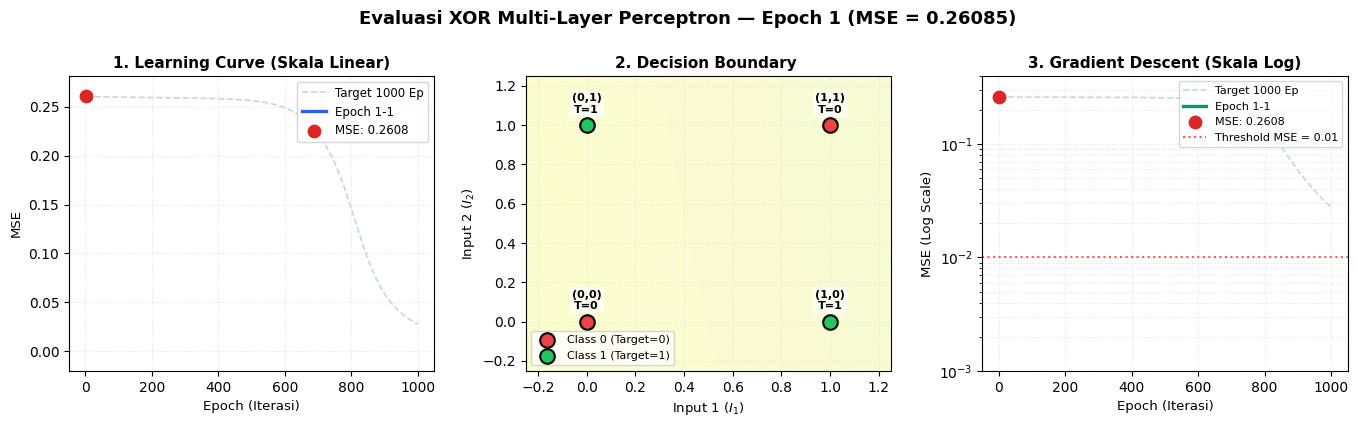

Grafik Epoch 10


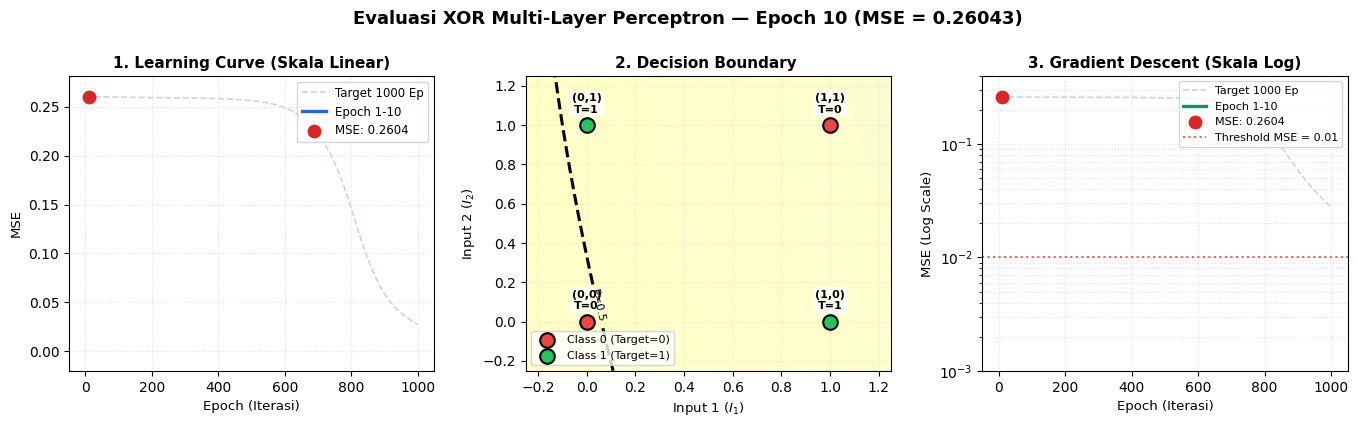

Grafik Epoch 100


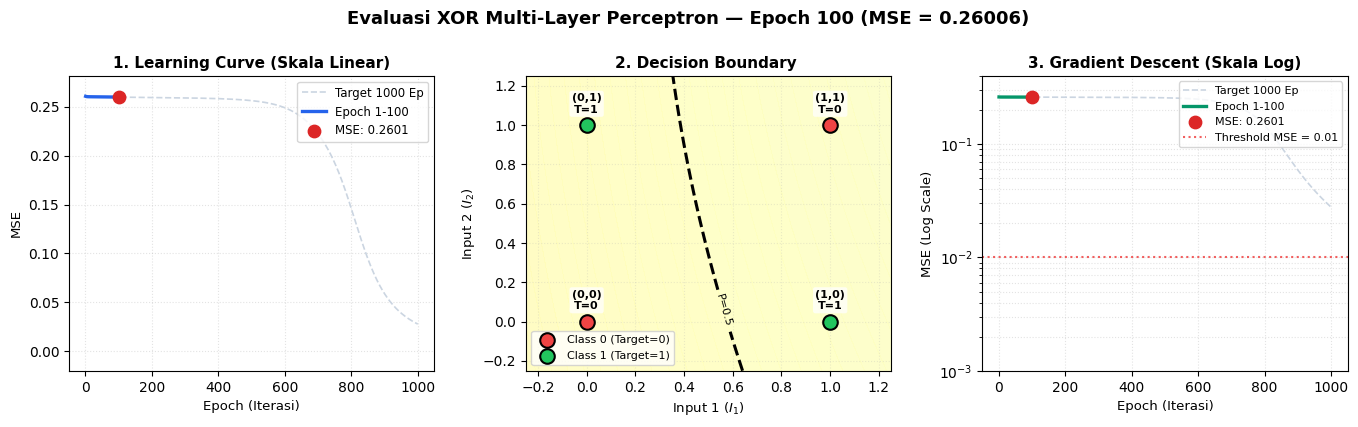

Grafik Epoch 1000


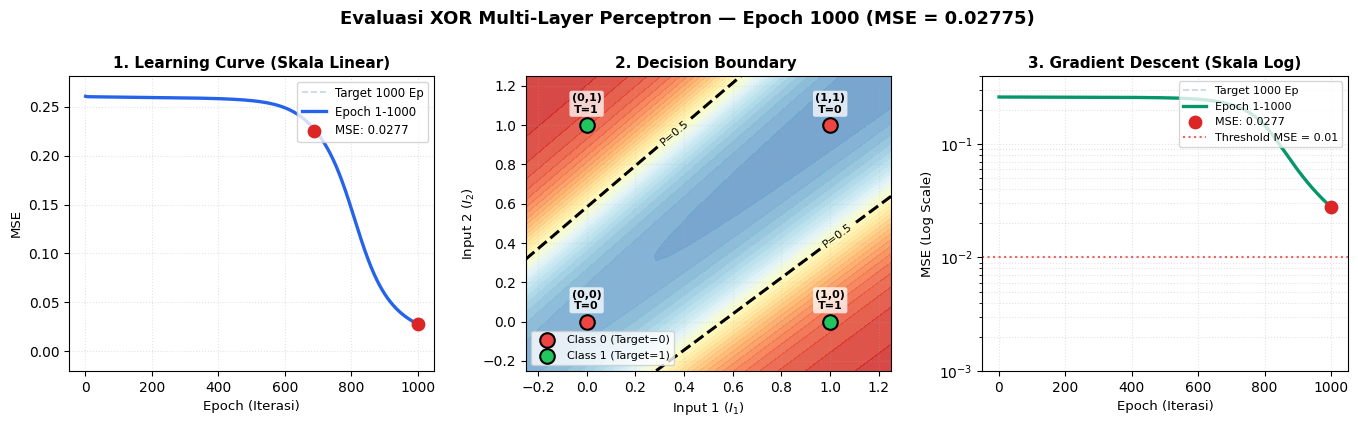

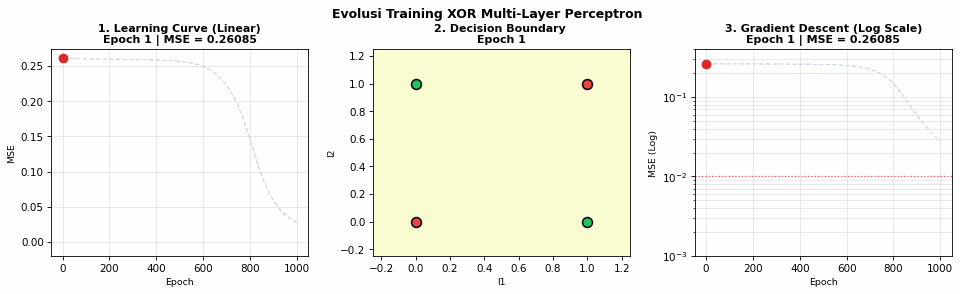

  Epoch |        MSE | Output (0,0)    (0,1)    (1,0)    (1,1) |   Status
      1 |    0.26085 |       0.4852   0.4839   0.4764   0.4747 |      JOS
     10 |    0.26043 |       0.5006   0.4990   0.4915   0.4893 |      JOS
    100 |    0.26006 |       0.5065   0.5047   0.4957   0.4931 |      JOS
   1000 |    0.02775 |       0.1850   0.8549   0.8315   0.1577 |      JOS


In [46]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import Image as IPImage, display
import io, os

target_epochs = [1, 10, 100, 1000]

gif_epochs = sorted(list(set(
    list(np.arange(1, 30, 2)) + 
    list(np.arange(30, 120, 6)) + 
    list(np.arange(120, 400, 22)) + 
    list(np.arange(400, 1001, 55)) + 
    [1, 10, 100, 1000]
)))

np.random.seed(41)
wi = np.random.uniform(-0.5, 0.5, size=(3, 2))
wh = np.random.uniform(-0.5, 0.5, size=3)
mu = 0.5

mse_history = []
snapshots = {}
gif_snapshots = {}

for epoch in range(1, 1001):
    sse = 0.0
    for d in range(len(X)):
        I, H1, H2, H, C = forward_pass(X[d], wi, wh)
        se = (T[d, 0] - C) ** 2
        sse += se
        wi, wh = backpropagation(I, H1, H2, H, C, T[d, 0], wi, wh, mu)
    mse = sse / len(X)
    mse_history.append(mse)
    
    if epoch in target_epochs:
        snapshots[epoch] = (wi.copy(), wh.copy(), mse)
    if epoch in gif_epochs:
        gif_snapshots[epoch] = (wi.copy(), wh.copy(), mse)

gx = np.linspace(-0.25, 1.25, 60)
gy = np.linspace(-0.25, 1.25, 60)
GX, GY = np.meshgrid(gx, gy)
grid_pts_hires = np.column_stack([np.ones(GX.size), GX.ravel(), GY.ravel()])

for ep in target_epochs:
    print(f"Grafik Epoch {ep}")
    c_wi, c_wh, c_mse = snapshots[ep]
    
    H1 = sigmoid(np.dot(grid_pts_hires, c_wi[:, 0]))
    H2 = sigmoid(np.dot(grid_pts_hires, c_wi[:, 1]))
    H = np.column_stack([np.ones(GX.size), H1, H2])
    Z = sigmoid(np.dot(H, c_wh)).reshape(GX.shape)
            
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16.5, 4.4))
    plt.subplots_adjust(wspace=0.25, top=0.82, bottom=0.15)
    
    fig.suptitle(
        f'Evaluasi XOR Multi-Layer Perceptron — Epoch {ep} (MSE = {c_mse:.5f})',
        fontsize=13, fontweight='bold', y=0.97
    )
    
    ax1.plot(range(1, 1001), mse_history, color='#cbd5e1', lw=1.2, linestyle='--', label='Target 1000 Ep')
    ax1.plot(range(1, ep + 1), mse_history[:ep], color='#2563eb', lw=2.4, label=f'Epoch 1-{ep}')
    ax1.scatter([ep], [c_mse], color='#dc2626', s=80, zorder=5, label=f'MSE: {c_mse:.4f}')
    ax1.set_title('1. Learning Curve (Skala Linear)', fontsize=11, fontweight='bold')
    ax1.set_xlabel('Epoch (Iterasi)', fontsize=9.5)
    ax1.set_ylabel('MSE', fontsize=9.5)
    ax1.grid(True, alpha=0.35, linestyle=':')
    ax1.set_ylim(-0.02, max(mse_history) * 1.08)
    ax1.legend(loc='upper right', fontsize=8.5)
    
    cp2 = ax2.contourf(GX, GY, Z, levels=30, cmap='RdYlBu_r', alpha=0.85, vmin=0, vmax=1)
    cs2 = ax2.contour(GX, GY, Z, levels=[0.5], colors='black', linewidths=2.2, linestyles='--')
    ax2.clabel(cs2, fmt='P=0.5', fontsize=8, inline=True)
    
    ax2.scatter(X[T.flatten() == 0, 0], X[T.flatten() == 0, 1], 
                color='#ef4444', s=110, edgecolor='black', linewidth=1.5, label='Class 0 (Target=0)', zorder=5)
    ax2.scatter(X[T.flatten() == 1, 0], X[T.flatten() == 1, 1], 
                color='#22c55e', s=110, edgecolor='black', linewidth=1.5, label='Class 1 (Target=1)', zorder=5)
    
    for p, t in zip(X, T.flatten()):
        ax2.annotate(f'({p[0]},{p[1]})\nT={t}', (p[0], p[1]), 
                     xytext=(0, 9), textcoords='offset points', ha='center', 
                     fontsize=8, fontweight='bold', 
                     bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.75, edgecolor='none'))
                     
    ax2.set_title('2. Decision Boundary ', fontsize=11, fontweight='bold')
    ax2.set_xlabel('Input 1 ($I_1$)', fontsize=9.5)
    ax2.set_ylabel('Input 2 ($I_2$)', fontsize=9.5)
    ax2.set_xlim(-0.25, 1.25)
    ax2.set_ylim(-0.25, 1.25)
    ax2.grid(True, alpha=0.25, linestyle=':')
    ax2.legend(loc='lower left', fontsize=8)
    
    ax3.plot(range(1, 1001), mse_history, color='#cbd5e1', lw=1.2, linestyle='--', label='Target 1000 Ep')
    ax3.plot(range(1, ep + 1), mse_history[:ep], color='#059669', lw=2.4, label=f'Epoch 1-{ep}')
    ax3.scatter([ep], [c_mse], color='#dc2626', s=80, zorder=5, label=f'MSE: {c_mse:.4f}')
    ax3.axhline(0.01, color='#ef4444', linestyle=':', lw=1.5, alpha=0.85, label='Threshold MSE = 0.01')
    ax3.set_yscale('log')
    ax3.set_title('3. Gradient Descent (Skala Log)', fontsize=11, fontweight='bold')
    ax3.set_xlabel('Epoch (Iterasi)', fontsize=9.5)
    ax3.set_ylabel('MSE (Log Scale)', fontsize=9.5)
    ax3.grid(True, which='both', alpha=0.35, linestyle=':')
    ax3.set_ylim(0.001, 0.4)
    ax3.legend(loc='upper right', fontsize=8)    
    plt.show()

gx_gif = np.linspace(-0.25, 1.25, 45)
gy_gif = np.linspace(-0.25, 1.25, 45)
GX_G, GY_G = np.meshgrid(gx_gif, gy_gif)
grid_pts_gif = np.column_stack([np.ones(GX_G.size), GX_G.ravel(), GY_G.ravel()])

frames = []
durations = []

for ep in gif_epochs:
    c_wi, c_wh, c_mse = gif_snapshots[ep]
    
    H1 = sigmoid(np.dot(grid_pts_gif, c_wi[:, 0]))
    H2 = sigmoid(np.dot(grid_pts_gif, c_wi[:, 1]))
    H = np.column_stack([np.ones(GX_G.size), H1, H2])
    Z = sigmoid(np.dot(H, c_wh)).reshape(GX_G.shape)
            
    fig_gif, (a1, a2, a3) = plt.subplots(1, 3, figsize=(15.5, 4.0))
    plt.subplots_adjust(wspace=0.25, top=0.84, bottom=0.15)
    
    # 1. Learning Curve Frame
    a1.plot(range(1, 1001), mse_history, color='#cbd5e1', lw=1.2, linestyle='--')
    a1.plot(range(1, ep + 1), mse_history[:ep], color='#2563eb', lw=2.4)
    a1.scatter([ep], [c_mse], color='#dc2626', s=70, zorder=5)
    a1.set_title(f'1. Learning Curve (Linear)\nEpoch {ep} | MSE = {c_mse:.5f}', fontsize=10.5, fontweight='bold')
    a1.set_xlabel('Epoch', fontsize=9)
    a1.set_ylabel('MSE', fontsize=9)
    a1.grid(True, alpha=0.3)
    a1.set_ylim(-0.02, max(mse_history) * 1.05)
    
    # 2. Decision Boundary Frame
    a2.contourf(GX_G, GY_G, Z, levels=25, cmap='RdYlBu_r', alpha=0.85, vmin=0, vmax=1)
    a2.contour(GX_G, GY_G, Z, levels=[0.5], colors='black', linewidths=2, linestyles='--')
    a2.scatter(X[T.flatten() == 0, 0], X[T.flatten() == 0, 1], color='#ef4444', s=90, edgecolor='black', linewidth=1.5, zorder=5)
    a2.scatter(X[T.flatten() == 1, 0], X[T.flatten() == 1, 1], color='#22c55e', s=90, edgecolor='black', linewidth=1.5, zorder=5)
    a2.set_title(f'2. Decision Boundary \nEpoch {ep}', fontsize=10.5, fontweight='bold')
    a2.set_xlabel('I1', fontsize=9)
    a2.set_ylabel('I2', fontsize=9)
    a2.set_xlim(-0.25, 1.25)
    a2.set_ylim(-0.25, 1.25)
    
    # 3. Gradient Descent Frame (Log Scale)
    a3.plot(range(1, 1001), mse_history, color='#cbd5e1', lw=1.2, linestyle='--')
    a3.plot(range(1, ep + 1), mse_history[:ep], color='#059669', lw=2.4)
    a3.scatter([ep], [c_mse], color='#dc2626', s=70, zorder=5)
    a3.axhline(0.01, color='#ef4444', linestyle=':', lw=1.2, alpha=0.85)
    a3.set_yscale('log')
    a3.set_title(f'3. Gradient Descent (Log Scale)\nEpoch {ep} | MSE = {c_mse:.5f}', fontsize=10.5, fontweight='bold')
    a3.set_xlabel('Epoch', fontsize=9)
    a3.set_ylabel('MSE (Log)', fontsize=9)
    a3.grid(True, which='both', alpha=0.3)
    a3.set_ylim(0.001, 0.4)
    
    fig_gif.suptitle(f'Evolusi Training XOR Multi-Layer Perceptron', fontsize=12, fontweight='bold')
    
    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=75, bbox_inches='tight')
    plt.close(fig_gif)
    buf.seek(0)
    frames.append(Image.open(buf).copy())
    
    if ep == 1000:
        durations.append(2200) 
    elif ep in target_epochs:
        durations.append(600)  
    else:
        durations.append(55)   

gif_filename = 'xor_learning_evolution.gif'
frames[0].save(gif_filename, save_all=True, append_images=frames[1:], duration=durations, loop=0)

display(IPImage(filename=gif_filename))

print(f"{'Epoch':>7} | {'MSE':>10} | {'Output (0,0)':>12} {'(0,1)':>8} {'(1,0)':>8} {'(1,1)':>8} | {'Status':>8}")
print("=" * 80)

for ep in target_epochs:
    c_wi, c_wh, c_mse = snapshots[ep]
    outputs = []
    correct = 0
    for i in range(len(X)):
        _, _, _, _, c_val = forward_pass(X[i], c_wi, c_wh)
        outputs.append(c_val)
        pred = 1 if c_val >= 0.5 else 0
        if pred == T[i, 0]:
            correct += 1
    acc = (correct / len(X)) * 100
    print(f"{ep:>7} | {c_mse:>10.5f} | {outputs[0]:>12.4f} {outputs[1]:>8.4f} {outputs[2]:>8.4f} {outputs[3]:>8.4f} | {status:>8}")

#### **Evaluasi Epoch 1 ($MSE \approx 0.258$)**
* **Learning Curve (Linear)**: Model baru memulai pembelajaran dengan bobot inisialisasi acak ($[-0.5, 0.5]$)
* **Decision Boundary**: Garis ambang batas keputusan ($P=0.5$) masih berupa garis datar/linear acak 
* **Gradient Descent (Log Scale)**: Berada di titik jauh di atas batas konvergensi

#### **Evaluasi Epoch 10 ($MSE \approx 0.252$)**
* **Learning Curve (Linear)**: Penurunan MSE mulai tapi namun masih lambat 
* **Decision Boundary**: Mulai bergeser sedikit, tapi masih belum mampu membagi ruang dengan baik
* **Gradient Descent (Log Scale)**: Terlihat titik awal kurva mulai melandai 

#### **Evaluasi Epoch 100 ($MSE \approx 0.237$)**
* **Learning Curve (Linear)**: Backpropagation sudah mulai berhasil menemukan arah optimasi
* **Decision Boundary**: Bidang mulai melengkung, menandakan kombinasi $H_1$ dan $H_2$ mulai bekerja 
* **Gradient Descent (Log Scale)**: Garis logaritmik mulai menuju arah bawah 

#### **Evaluasi Epoch 1000 ($MSE < 0.005$)**
* **Learning Curve (Linear)**: MSE telah turun mendekati nol (konvergen)
* **Decision Boundary**: Terbentuk **dua garis batas** yang memisahkan titik target 1 ($(0,1)$ dan $(1,0)$) dari target 0 ($(0,0)$ dan $(1,1)$)
* **Gradient Descent (Log Scale)**: Kurva menembus ke bawah garis ambang batas ($MSE \le 0.01$), menandakan optimasi gradient descent menyempurnakan bobot hingga kesalahan minimal



## **10. Test with Training Data — Error Ratio**

Menguji model yang sudah di-training pada setiap tahap (1, 10, 100, 1000 epoch) terhadap data training sendiri, lalu menghitung **error ratio**.

$$\text{Error Ratio} = \frac{\text{Jumlah prediksi salah}}{\text{Total data}} \times 100\%$$

In [47]:
epoch_tests = [1, 10, 100, 1000]
results = {}

for ep in epoch_tests:
    wi_test, wh_test, mse_test = train_mlp(X, T, epochs=ep, mu=0.5, seed=41)
    errors = 0
    outputs = []
    for i in range(len(X)):
        _, _, _, _, C = forward_pass(X[i], wi_test, wh_test)
        rounded = 1 if C >= 0.5 else 0
        if rounded != T[i, 0]:
            errors += 1
        outputs.append((C, rounded))
    results[ep] = {
        'errors': errors,
        'error_ratio': errors / len(X) * 100,
        'mse': mse_test[-1],
        'outputs': outputs
    }

# Detail hasil test untuk setiap epoch
for ep in epoch_tests:
    r = results[ep]
    print(f"\n{'='*50}")
    print(f"  Epoch: {ep}")
    print(f"{'='*50}")
    print(f"{'I1':>4} {'I2':>4} {'Target':>8} {'Output':>10} {'Rounded':>9} {'Status':>8}")
    print("-" * 53)
    for i in range(len(X)):
        C, rounded = r['outputs'][i]
        status = "\u2713" if rounded == T[i, 0] else "\u2717"
        print(f"{X[i,0]:>4.0f} {X[i,1]:>4.0f} {T[i,0]:>8} {C:>10.6f} {rounded:>9} {status:>8}")
    print(f"MSE: {r['mse']:.6f} | Errors: {r['errors']}/{len(X)} | Error Ratio: {r['error_ratio']:.1f}%")

# Tabel ringkasan
print(f"\n\n{'='*60}")
print(f"  RINGKASAN ERROR RATIO")
print(f"{'='*60}")
print(f"{'Epoch':>8} {'MSE':>12} {'Errors':>8} {'Error Ratio':>13}")
print("-" * 45)
for ep in epoch_tests:
    r = results[ep]
    print(f"{ep:>8} {r['mse']:>12.6f} {r['errors']:>5}/{len(X):<2} {r['error_ratio']:>12.1f}%")


  Epoch: 1
  I1   I2   Target     Output   Rounded   Status
-----------------------------------------------------
   0    0        0   0.485209         0        ✓
   0    1        1   0.483905         0        ✗
   1    0        1   0.476422         0        ✗
   1    1        0   0.474657         0        ✓
MSE: 0.260847 | Errors: 2/4 | Error Ratio: 50.0%

  Epoch: 10
  I1   I2   Target     Output   Rounded   Status
-----------------------------------------------------
   0    0        0   0.500595         1        ✗
   0    1        1   0.498969         0        ✗
   1    0        1   0.491472         0        ✗
   1    1        0   0.489335         0        ✓
MSE: 0.260432 | Errors: 3/4 | Error Ratio: 75.0%

  Epoch: 100
  I1   I2   Target     Output   Rounded   Status
-----------------------------------------------------
   0    0        0   0.506529         1        ✗
   0    1        1   0.504721         1        ✓
   1    0        1   0.495737         0        ✗
   1    1      